In [241]:
# The libraries 
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1

In [242]:
# Filesystems to compare
filesystems = ["ext4", "xfs", "btrfs", "ntfs", "vfat"]

# Store all benchmark rows
dfs = []

def to_ms(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).strip().lower()

    if x.endswith("us"):
        return float(x.replace("us", "")) / 1000.0
    elif x.endswith("ms"):
        return float(x.replace("ms", ""))
    else:
        return np.nan
    
for fs in filesystems:
  paths = [
      f"./{fs}/out/ondemand/*.log",
      f"./{fs}/out_with_file_creation/ondemand/*.log"
  ]

  for path in paths:
    for file in glob.glob(path):

      # Extract benchmark size from filename
      size = int(os.path.basename(file).replace(".log", ""))

      # Load CSV-like bonnie++ output
      df = pd.read_csv(file)

      # Add metadata columns
      df["filesystem"] = fs
      df["size"] = size
      
      dfs.append(df)

# Combine everything
data = pd.concat(dfs, ignore_index=True)

# Clean data
throughput_cols = [
   "put_block", 
   "get_block",
   "rewrite",
   "seq_create",
   "ran_create"
]

latency_cols = [
    "put_block_latency",
    "get_block_latency",
    "rewrite_latency",
    "seq_create_latency",
    "ran_create_latency"
]

for col in throughput_cols:
  if col in data.columns:
    # Remove "+++++" overflow values
    data[col] = pd.to_numeric(data[col], errors="coerce")

    # Convert throughput to numeric
    data[col] = pd.to_numeric(data[col])

for col in latency_cols:
    
    if col in data.columns:
        data[col] = data[col].apply(to_ms)

data.head()

,format_version,bonnie_version,name,concurrency,seed,file_size,io_chunk_size,putc,putc_cpu,put_block,...,get_block_latency,seeks_latency,seq_create_latency,seq_stat_latency,seq_del_latency,ran_create_latency,ran_stat_latency,ran_del_latency,filesystem,size
0,chasseral-1,1,42,4M,NaN,0,0,340,99,NaN,...,0.023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ext4,4
1,chasseral-1,1,42,4M,NaN,0,0,340,99,NaN,...,0.020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ext4,4
2,chasseral-1,1,42,4M,NaN,0,0,345,99,NaN,...,0.015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ext4,4
3,chasseral-1,1,42,4M,NaN,0,0,344,99,NaN,...,0.023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ext4,4
4,chasseral-1,1,42,4M,NaN,0,0,346,99,NaN,...,0.019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ext4,4


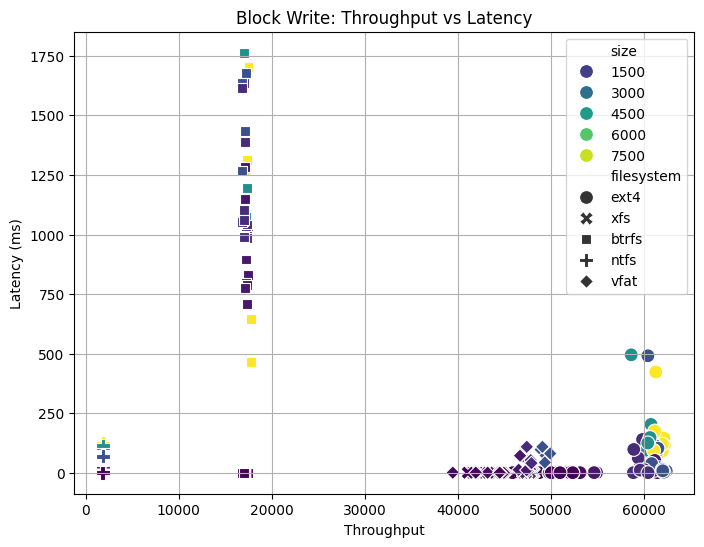

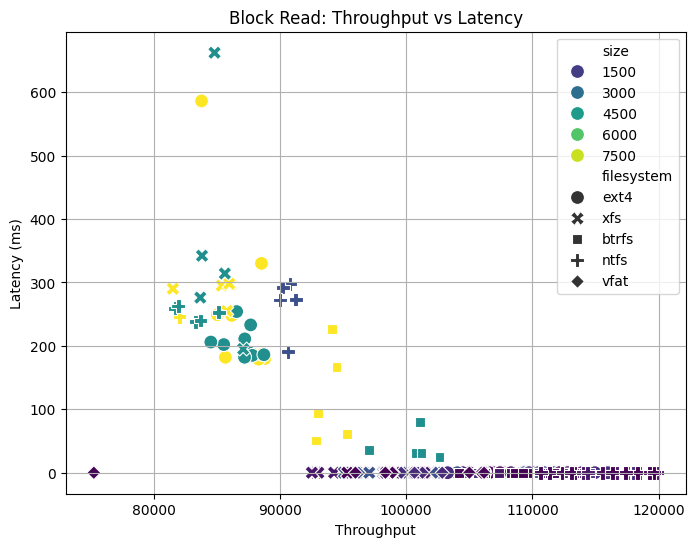

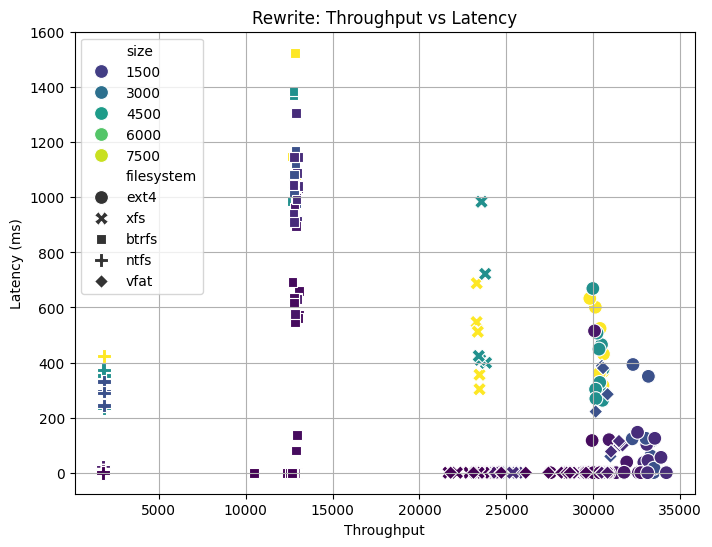

In [243]:
# -----------------------------
# FILE I/O TESTS
# -----------------------------

# Metrics to compare
io_tests = [
    ("put_block", "put_block_latency", "Block Write"),
    ("get_block", "get_block_latency", "Block Read"),
    ("rewrite", "rewrite_latency", "Rewrite"),
]

for throughput_col, latency_col, title in io_tests:

    # Remove invalid rows
    plot_data = data.dropna(subset=[throughput_col, latency_col])

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        data=plot_data,
        x=throughput_col,
        y=latency_col,
        hue="size",
        style="filesystem",
        palette="viridis",
        s=100
    )

    plt.title(f"{title}: Throughput vs Latency")
    plt.xlabel("Throughput")
    plt.ylabel("Latency (ms)")
    plt.grid(True)

    plt.savefig(f"Task 1 {title}.png", dpi=150)

    plt.show()

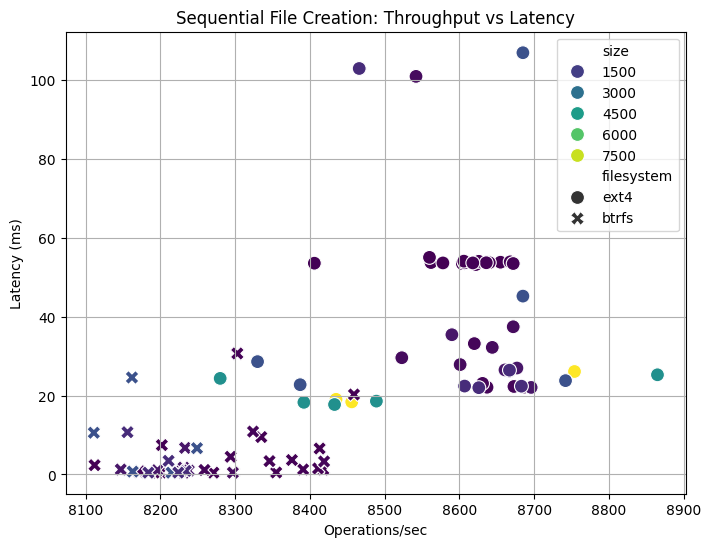

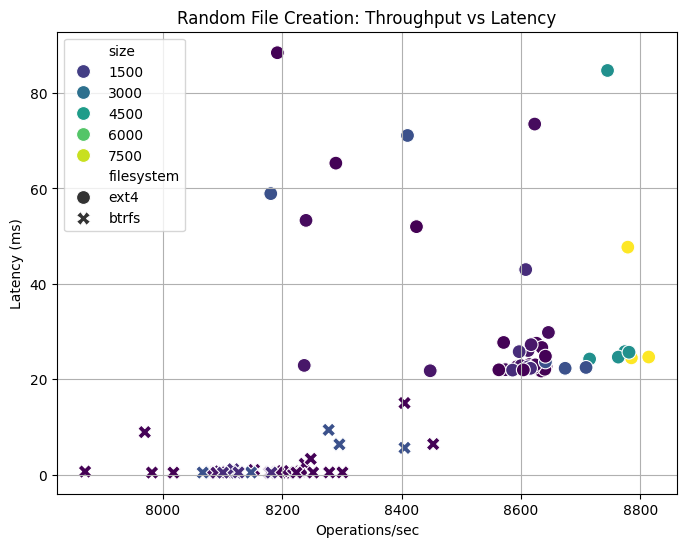

In [244]:
# -----------------------------
# FILE CREATION TESTS
# -----------------------------

creation_tests = [
    ("seq_create", "seq_create_latency", "Sequential File Creation"),
    ("ran_create", "ran_create_latency", "Random File Creation"),
]

for throughput_col, latency_col, title in creation_tests:
    plot_data = data.dropna(subset=[throughput_col, latency_col]).copy()

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        data=plot_data,
        x=throughput_col,
        y=latency_col,
        hue="size",
        style="filesystem",
        palette="viridis",
        s=100
    )

    plt.title(f"{title}: Throughput vs Latency")
    plt.xlabel("Operations/sec")
    plt.ylabel("Latency (ms)")
    plt.grid(True)

    plt.savefig(f"Task 1 {title}.png", dpi=150)

    plt.show()

# Task 2

In [245]:
disk_data = data.copy()

tmpfs_dfs = []
for file in glob.glob("./tmpfs/out/ondemand/*.log"):
    size = int(os.path.basename(file).replace(".log", ""))

    df = pd.read_csv(file)

    df["filesystem"] = "tmpfs"
    df["size"] = size

    tmpfs_dfs.append(df)

tmpfs_data = pd.concat(tmpfs_dfs, ignore_index=True)

for col in throughput_cols:
    if col in tmpfs_data.columns:
        tmpfs_data[col] = tmpfs_data[col].replace("+++++", np.nan)
        tmpfs_data[col] = pd.to_numeric(tmpfs_data[col], errors="coerce")

for col in latency_cols:
    if col in tmpfs_data.columns:
        tmpfs_data[col] = tmpfs_data[col].apply(to_ms)
   
tmpfs_data["type"] = "ram"
disk_data["type"] = "disk"

all_data = pd.concat([disk_data, tmpfs_data], ignore_index=True)

/var/folders/4c/dksdqz190wq3kkq3t17dyspc0000gn/T/ipykernel_26923/1969365066.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tmpfs_data[col] = tmpfs_data[col].replace("+++++", np.nan)


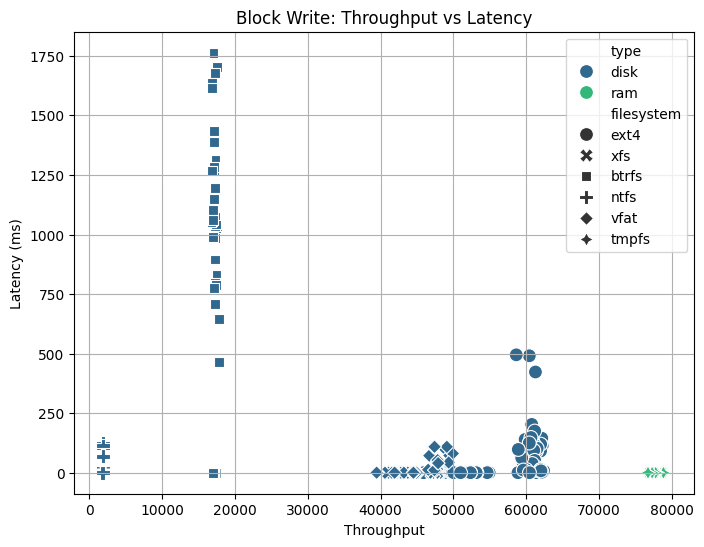

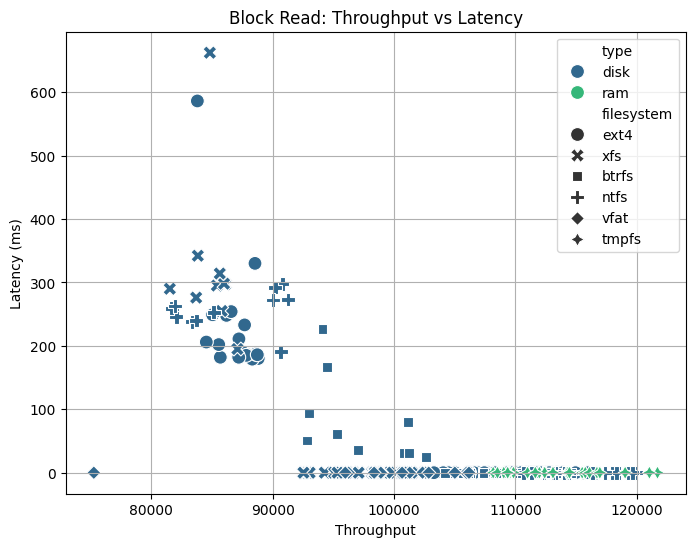

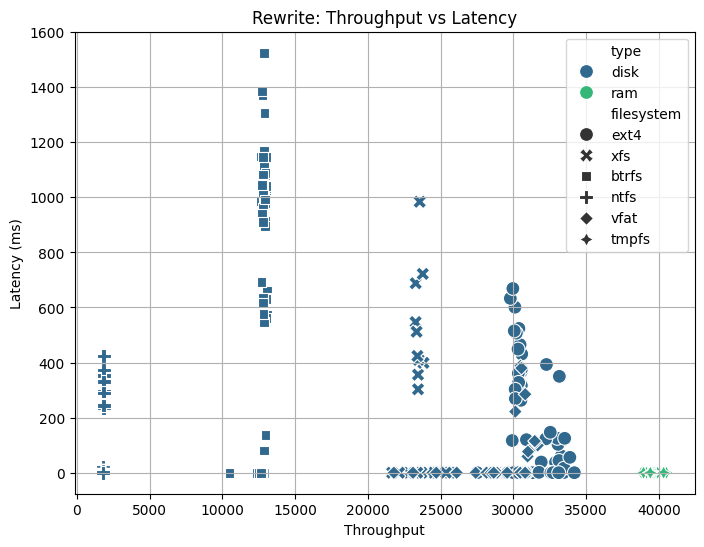

In [246]:
# -----------------------------
# TASK 2: FILE I/O TESTS
# -----------------------------

# Metrics to compare
io_tests = [
    ("put_block", "put_block_latency", "Block Write"),
    ("get_block", "get_block_latency", "Block Read"),
    ("rewrite", "rewrite_latency", "Rewrite"),
]

for throughput_col, latency_col, title in io_tests:

    # Remove invalid rows
    plot_data = all_data.dropna(subset=[throughput_col, latency_col])

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        data=plot_data,
        x=throughput_col,
        y=latency_col,
        hue="type",
        style="filesystem",
        palette="viridis",
        s=100
    )

    plt.title(f"{title}: Throughput vs Latency")
    plt.xlabel("Throughput")
    plt.ylabel("Latency (ms)")
    plt.grid(True)

    plt.savefig(f"Task 2 {title}.png", dpi=150)

    plt.show()